In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import logging
import joblib

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

from src.helper import *

In [2]:
#set config
DATA_PATH = "data/deep-detect/dataset/"
OUTPUT_PATH = "output/"
PREDS_PATH = "output/preds/"
MODELS_PATH = "models/"

DATASET_PATH = "output/nb_01__train_test_holdout_feats.csv"

In [3]:
if not os.path.exists(OUTPUT_PATH):
    os.mkdir(OUTPUT_PATH)
if not os.path.exists(PREDS_PATH):
    os.mkdir(PREDS_PATH)
if not os.path.exists(MODELS_PATH):
    os.mkdir(MODELS_PATH)

In [4]:
# --- Setup logging ---
logging.basicConfig(
    filename=os.path.join(OUTPUT_PATH, f"nb_02_ml_benchmark_models_log.log"),
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger("Main")
logger.info(f"starting ML benchmark models...")

In [5]:
logger.info(f"reading dataset from {DATASET_PATH}...")
df_dataset = pd.read_csv(DATASET_PATH)
df_dataset['label'] = np.where(
    df_dataset['label']=='real',
    0,
    np.where(
        df_dataset['label']=='fake',
        1,
        np.nan
    )
)
logger.info(f"dataset shape : {df_dataset.shape}")
df_dataset.head(3)

,filepath,filename,split,label,duration,sample_rate,rms_energy,zero_crossing_rate,spectral_centroid,spectral_bandwidth,...,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std
0,data/deep-detect/dataset/holdout/audio_06718.wav,audio_06718.wav,holdout,NaN,2.952,16000.0,0.041040,0.165160,1770.421519,1430.811785,...,-358.556580,192.676102,61.244213,68.014946,6.321727,23.635677,17.305662,32.447296,-8.661601,23.757639
1,data/deep-detect/dataset/holdout/audio_00530.wav,audio_00530.wav,holdout,NaN,5.742,16000.0,0.008138,0.127596,1722.722619,1593.515970,...,-464.518829,99.572281,95.552780,48.394844,-0.713542,38.529541,0.020048,27.348408,-4.268337,19.990133
2,data/deep-detect/dataset/holdout/audio_12760.wav,audio_12760.wav,holdout,NaN,1.431,16000.0,0.025449,0.125467,1871.679940,1713.004875,...,-304.998291,98.922905,80.585861,30.346718,-9.771561,27.919638,21.988018,13.912403,-10.379161,21.056404


In [6]:
feature_cols = [c for c in df_dataset.columns if c not in ('filepath', 'filename', 'split', 'label')]
id_col = "filename"
label_col = "label"

X_train = df_dataset.loc[df_dataset['split']=='training'].set_index(id_col)[feature_cols].copy()
y_train = df_dataset.loc[df_dataset['split']=='training'].set_index(id_col)[label_col].copy()

logger.info(f"X_train shape : {X_train.shape}")
logger.info(f"y_train shape : {y_train.shape}")

X_test = df_dataset.loc[df_dataset['split']=='testing'].set_index(id_col)[feature_cols].copy()
y_test = df_dataset.loc[df_dataset['split']=='testing'].set_index(id_col)[label_col].copy()

logger.info(f"X_test shape : {X_test.shape}")
logger.info(f"y_test shape : {y_test.shape}")

X_holdout = df_dataset.loc[df_dataset['split']=='holdout'].set_index(id_col)[feature_cols].copy()
y_holdout = df_dataset.loc[df_dataset['split']=='holdout'].set_index(id_col)[label_col].copy()

logger.info(f"X_holdout shape : {X_holdout.shape}")
logger.info(f"y_holdout shape : {y_holdout.shape}")

### Experiments

In [7]:
models_dict = {
    'logreg': LogisticRegression(),
    'knn': KNeighborsClassifier(),
    'rf': RandomForestClassifier(),
    'lgbm': LGBMClassifier(),
    'xgb': XGBClassifier(),
    'catboost': CatBoostClassifier(),
}

In [ ]:
for name, model in models_dict.items():
    logger.info(f"starting training for {name} model...")

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ('scaler', RobustScaler()),
        ('classifier', model)
    ])
    #get cross validation score
    cv_score = cross_val_score(pipe, X_train.copy(), y_train.copy(), scoring='f1', cv=5).mean()

    #get score on testing set
    pipe.fit(X_train.copy(), y_train.copy())
    y_test_preds = pipe.predict(X_test.copy())
    test_score = f1_score(y_test, y_test_preds)

    #get score summary
    logger.info(f"{name} cv f1-score: {cv_score}")
    logger.info(f"{name} test f1-score: {test_score}")
    logger.info(f"{name} classification report: \n{classification_report(y_test, y_test_preds)}")

    #save model to joblib
    model_save_path = os.path.join(MODELS_PATH, f'nb_02__{name}_ml_benchmark_model.joblib')
    joblib.dump(pipe, model_save_path)
    logger.info(f"{name} model saved to {model_save_path}")

    #get holdout predictions
    preds_save_path = os.path.join(PREDS_PATH, f'nb_02__{name}_ml_benchmark_model_preds.csv')
    df_holdout_preds = pd.DataFrame()
    df_holdout_preds['id'] = X_holdout.index
    df_holdout_preds['label'] = pipe.predict(X_holdout.copy())
    df_holdout_preds['label'] = df_holdout_preds['label'].astype(int)
    df_holdout_preds.to_csv(preds_save_path, index=False)
    logger.info(f"{name} model holdout preds saved to {preds_save_path}")

In [10]:
logger.info(f"""
Results on kaggle leaderboard:
- logreg: 0.87175
- knn: 0.98699
- rf: 0.98290
- lgbm: 0.98324
- xgb: 0.98690
- catboost: 0.98888
""")

### Exploring result of best model (catboost)

Key takeaways:
- Binary separation chart shows a good separation of predicted probabilities, even only using a few features and vanilla ML models.
- Most important features are MFCC features, duration, and spectral flatness.

In [8]:
best_model = joblib.load(os.path.join(MODELS_PATH, "nb_02__catboost_ml_benchmark_model.joblib"))
best_model

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


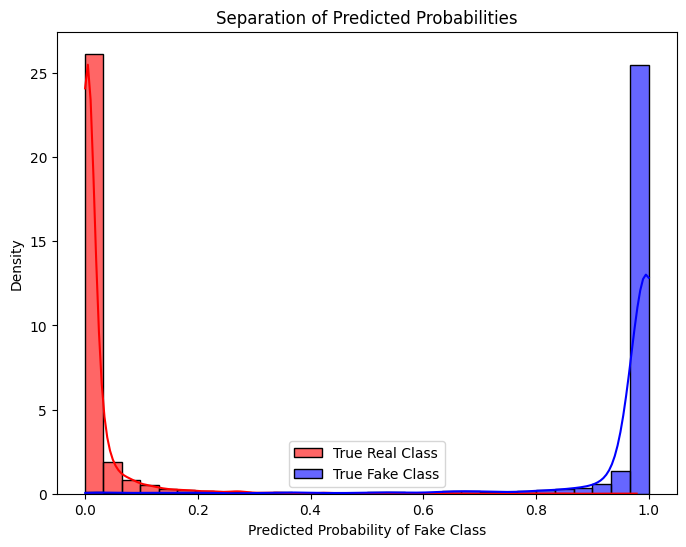

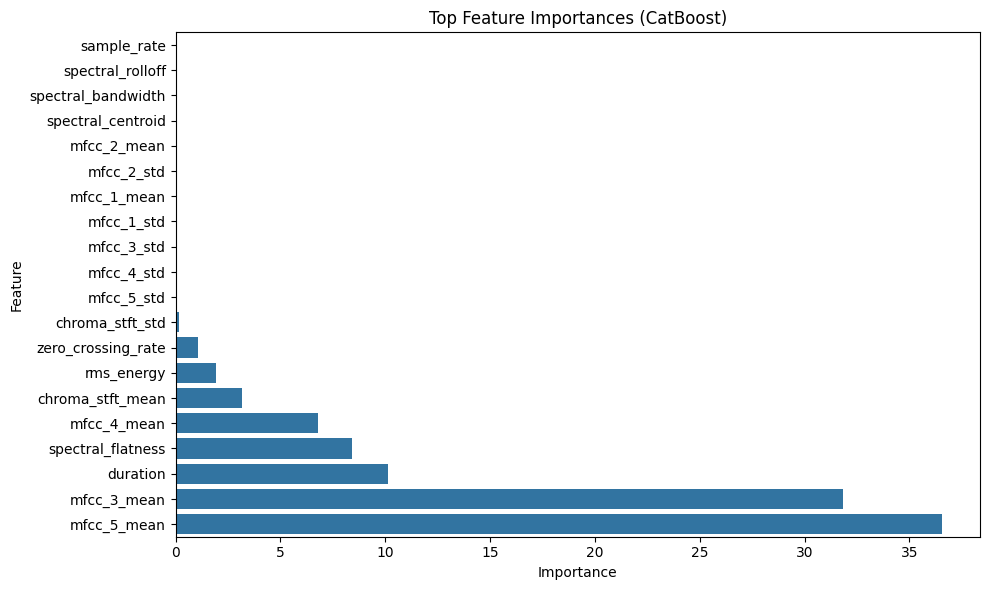

In [18]:
# Get predictions
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_proba_label = (y_test_proba >= 0.5).astype(int)

# ------------------------
# 1. Binary separation chart
# ------------------------
plt.figure(figsize=(8, 6))
sns.histplot(y_test_proba[y_test == 0], color="red", label="True Real Class", kde=True, stat="density", bins=30, alpha=0.6)
sns.histplot(y_test_proba[y_test == 1], color="blue", label="True Fake Class", kde=True, stat="density", bins=30, alpha=0.6)
plt.title("Separation of Predicted Probabilities")
plt.xlabel("Predicted Probability of Fake Class")
plt.ylabel("Density")
plt.legend()
plt.show()

# ------------------------
# 2. Feature importance
# ------------------------
feature_importances = best_model.named_steps['classifier'].get_feature_importance(Pool(X_test, y_test))
df_feat_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=df_feat_imp)
plt.title("Top Feature Importances (CatBoost)")
plt.tight_layout()
plt.show()